In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical models
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scipy for chi-square tests
from scipy import stats

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# 0.2  Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:


import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

In [5]:
from pathlib import Path

In [7]:
# Define paths
DATA_PATH = Path("../../data/no_missing")

In [8]:
# Load data
df_raw = pd.read_excel(DATA_PATH / "complete_birth_2010.xlsx")

In [9]:
# 1.2  Load the file

print(f'File loaded successfully.')
print(f'  Rows    : {len(df_raw):,}')
print(f'  Columns : {df_raw.shape[1]}')
print(f'\nColumn names:')
for c in df_raw.columns:
    print(f'  {c}')

File loaded successfully.
  Rows    : 318,290
  Columns : 15

Column names:
  Registered_Year
  Registered_Month
  Registered_District
  Birh_Year
  Birth_Month
  Gender
  Hospital or Not
  Multiple_Birth_Status
  Birth_Weight(grams)
  Birth_Order
  Age of Mother
  Marital_Status
  District_of_Mother
  Race_of_Mother
  Race_of_Father


In [10]:
# 1.3  First look at the data
df_raw.head(5)

,Registered_Year,Registered_Month,Registered_District,Birh_Year,Birth_Month,Gender,Hospital or Not,Multiple_Birth_Status,Birth_Weight(grams),Birth_Order,Age of Mother,Marital_Status,District_of_Mother,Race_of_Mother,Race_of_Father
0,2010,November,Matara,2010,November,Male,Hospital,Singleton,2830,Second,32,Married,Matara,Sinhalese,Sinhalese
1,2010,November,Matara,2010,November,Male,Hospital,Singleton,2815,First,20,Married,Matara,Sinhalese,Sinhalese
2,2010,November,Matara,2010,November,Female,Hospital,Singleton,3890,Second,27,Married,Matara,Sinhalese,Sinhalese
3,2010,November,Matara,2010,November,Female,Hospital,Singleton,3080,Second,34,Married,Matara,Sinhalese,Sinhalese
4,2010,November,Matara,2010,November,Male,Hospital,Singleton,3145,First,21,Married,Matara,Sinhalese,Sinhalese


In [11]:
# 2.1  Work on a clean copy and standardise column names
df = df_raw.copy()

In [32]:
# 2.2  Rename columns to short working names
df = df.rename(columns={
    'Birth_Order'          : 'parity',
    'Age of Mother'        : 'maternal_age',
    'Marital_Status'       : 'marital_status',
    'Race_of_Mother'       : 'race_mother',
    'Race_of_Father'       : 'race_father',
    'Gender'               : 'child_sex',
    'Hospital_or_Not'      : 'place_delivery',
    'Multiple_Birth_Status': 'multiple_birth',
    'Birth_Weightgrams'    : 'birth_weight_g',
    'Registered_District'  : 'reg_district',
    'Registered_Year'      : 'reg_year',
    'Registered_Month'     : 'reg_month',
    'Birh_Year'            : 'birth_year',
    'Birth_Month'          : 'birth_month',
    'District_of_Mother'   : 'district_mother',
})

print('Working column names:')
print(df.columns.tolist())

Working column names:
['reg_year', 'reg_month', 'reg_district', 'birth_year', 'birth_month', 'child_sex', 'Hospital or Not', 'multiple_birth', 'Birth_Weight(grams)', 'parity', 'maternal_age', 'marital_status', 'district_mother', 'race_mother', 'race_father', 'parity_text', 'parity_binary', 'age_group']


In [23]:
# 2.3  Check unique Birth_Order text values before mapping
print('Unique values in Birth_Order column:')
print(df['parity'].value_counts(dropna=False))

Unique values in Birth_Order column:
parity
First      141383
Second     108642
Third       49739
Fourth      12941
Fifth        4007
Sixth        1040
Seventh       381
Eighth        124
Nineth         33
Name: count, dtype: int64


In [24]:
# 2.4  Map text parity labels to numeric 1–9
BIRTH_ORDER_MAP = {
    'First'  : 1,
    'Second' : 2,
    'Third'  : 3,
    'Fourth' : 4,
    'Fifth'  : 5,
    'Sixth'  : 6,
    'Seventh': 7,
    'Eighth' : 8,
    'Nineth' : 9,   # keeping original spelling from your data
}

# Strip accidental spaces then map
df['parity_text'] = df['parity'].astype(str).str.strip()  # save text version
df['parity'] = df['parity_text'].map(BIRTH_ORDER_MAP)     # overwrite with numeric

# Warn about any unmapped values
unmapped = df[df['parity'].isna()]['parity_text'].unique()
if len(unmapped) > 0:
    print(f'WARNING: Unmapped values found. Add these to BIRTH_ORDER_MAP: {unmapped}')
else:
    print('All parity labels mapped successfully.')

print('\nNumeric parity distribution:')
print(df['parity'].value_counts().sort_index())


All parity labels mapped successfully.

Numeric parity distribution:
parity
1    141383
2    108642
3     49739
4     12941
5      4007
6      1040
7       381
8       124
9        33
Name: count, dtype: int64


In [25]:
# 2.5  Create binary outcome for Model 3
# 1 = First-born  |  0 = Later-born (parity 2 to 9)
df['parity_binary'] = (df['parity'] == 1).astype(int)

print(f'First-born  (parity = 1) : {(df["parity_binary"]==1).sum():,}')
print(f'Later-born  (parity >= 2): {(df["parity_binary"]==0).sum():,}')
print(f'First-birth percentage   : {df["parity_binary"].mean()*100:.1f}%')

First-born  (parity = 1) : 141,383
Later-born  (parity >= 2): 176,907
First-birth percentage   : 44.4%


In [26]:
# 2.6  Maternal age — validate
df['maternal_age'] = pd.to_numeric(df['maternal_age'], errors='coerce')

print('Maternal age summary:')
print(df['maternal_age'].describe())

implaus = df[(df['maternal_age'] < 10) | (df['maternal_age'] > 60)]
print(f'\nImplausible age rows (<10 or >60): {len(implaus)}')

Maternal age summary:
count   318290.0000
mean        28.4537
std          5.7086
min         12.0000
25%         24.0000
50%         28.0000
75%         32.0000
max         54.0000
Name: maternal_age, dtype: float64

Implausible age rows (<10 or >60): 0


In [27]:
# 2.7  Categorize maternal age into 5 groups
age_bins   = [0, 19, 24, 29, 34, 120]
age_labels = ['<20', '20-24', '25-29', '30-34', '35+']

df['age_group'] = pd.cut(
    df['maternal_age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

print('Maternal age group distribution:')
print(df['age_group'].value_counts().sort_index())

Maternal age group distribution:
age_group
<20       17459
20-24     64997
25-29    103122
30-34     84405
35+       48307
Name: count, dtype: int64


In [33]:
print(df.columns.tolist())


['reg_year', 'reg_month', 'reg_district', 'birth_year', 'birth_month', 'child_sex', 'Hospital or Not', 'multiple_birth', 'Birth_Weight(grams)', 'parity', 'maternal_age', 'marital_status', 'district_mother', 'race_mother', 'race_father', 'parity_text', 'parity_binary', 'age_group']


In [31]:
# 2.8  Standardize categorical columns (strip spaces, consistent case)
CAT_COLS = ['child_sex', 'Hospital or Not', 'multiple_birth',
            'marital_status', 'race_mother', 'race_father']

for col in CAT_COLS:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace('Nan', np.nan)

# Check unique values after standardization
for col in CAT_COLS:
    print(f'\n{col}: {df[col].unique()}')


child_sex: <StringArray>
['Male', 'Female']
Length: 2, dtype: str

Hospital or Not: <StringArray>
['Hospital', 'Not In Hospital']
Length: 2, dtype: str

multiple_birth: <StringArray>
['Singleton', 'Triplets']
Length: 2, dtype: str

marital_status: <StringArray>
['Married', 'Unmarried']
Length: 2, dtype: str

race_mother: <StringArray>
[       'Sinhalese',   'Srilankan Moor',  'Srilankan Tamil',
          'Burgher',     'Indian Tamil', 'Other Srilankans',
            'Malay', 'Other Foreigners',    'Pakistan Moor',
      'Indian Moor',         'Bharatha', 'Srilankan Chetty']
Length: 12, dtype: str

race_father: <StringArray>
[       'Sinhalese',   'Srilankan Moor',  'Srilankan Tamil',
     'Indian Tamil',          'Burgher', 'Other Foreigners',
 'Other Srilankans',            'Malay',    'Pakistan Moor',
      'Indian Moor', 'Srilankan Chetty',         'Bharatha']
Length: 12, dtype: str


In [35]:
# 2.9  Remove implausible ages and drop rows missing key variables
KEY_VARS = [
    'parity', 'parity_binary', 'maternal_age', 'age_group',
    'child_sex', 'Hospital or Not', 'multiple_birth',
    'Birth_Weight(grams)', 'marital_status', 'race_mother'
]

df = df[(df['maternal_age'] >= 10) & (df['maternal_age'] <= 60)]

before = len(df)
df.dropna(subset=KEY_VARS, inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Rows before cleaning : {before:,}')
print(f'Rows after cleaning  : {after:,}')
print(f'Rows removed         : {before - after:,}  ({(before-after)/before*100:.1f}%)')

Rows before cleaning : 318,290
Rows after cleaning  : 318,290
Rows removed         : 0  (0.0%)


In [36]:
# 2.10  Final dataset summary
print('=' * 55)
print('FINAL CLEANED DATASET SUMMARY')
print('=' * 55)
print(f'Total records  : {len(df):,}')
print(f'Parity range   : {int(df["parity"].min())} to {int(df["parity"].max())}')
print(f'Maternal age   : {df["maternal_age"].min():.0f} to {df["maternal_age"].max():.0f} years')
print(f'First births   : {df["parity_binary"].sum():,}  ({df["parity_binary"].mean()*100:.1f}%)')
print('=' * 55)

FINAL CLEANED DATASET SUMMARY
Total records  : 318,290
Parity range   : 1 to 9
Maternal age   : 12 to 54 years
First births   : 141,383  (44.4%)


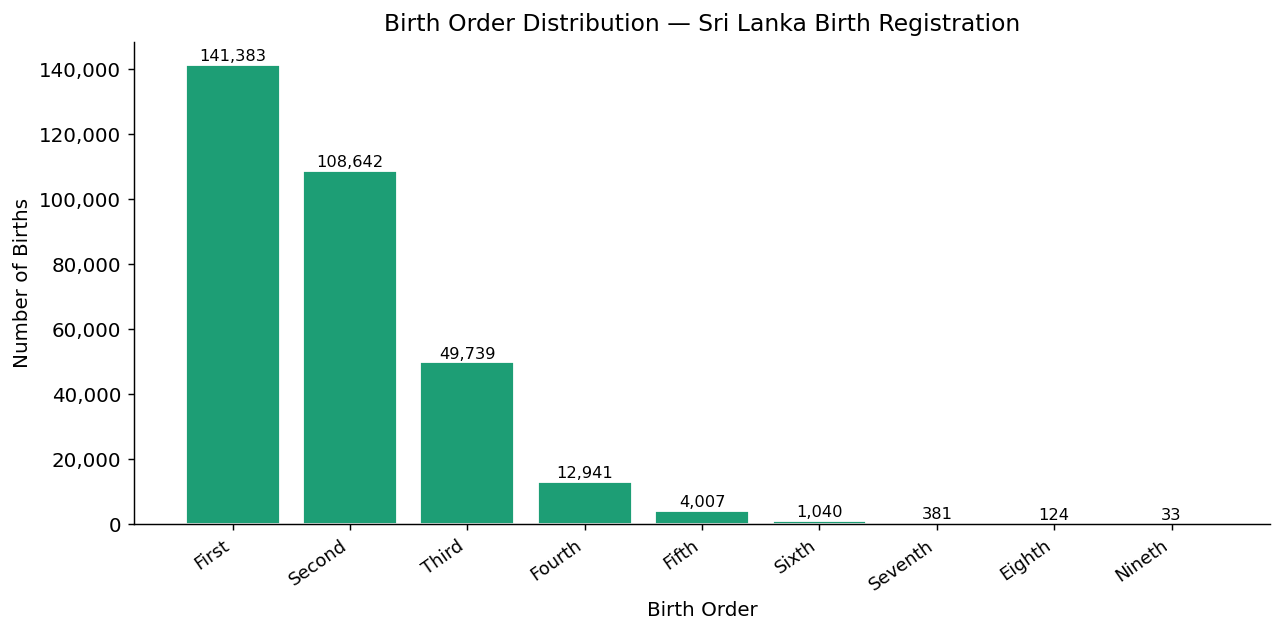

Saved: fig1_parity_distribution.png

Frequency Table:
Birth Order  Parity  Frequency  Percentage %  Cumulative %
      First       1     141383       44.4200       44.4200
     Second       2     108642       34.1300       78.5500
      Third       3      49739       15.6300       94.1800
     Fourth       4      12941        4.0700       98.2500
      Fifth       5       4007        1.2600       99.5000
      Sixth       6       1040        0.3300       99.8300
    Seventh       7        381        0.1200       99.9500
     Eighth       8        124        0.0400       99.9900
     Nineth       9         33        0.0100      100.0000

Word document saved: parity_distribution_report.docx


In [42]:
# 3.1  Parity distribution — count bar + frequency table → Word doc
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
import io

ORDER_LABELS = ['First','Second','Third','Fourth','Fifth',
                'Sixth','Seventh','Eighth','Nineth']

parity_counts = df['parity'].value_counts().sort_index()

# ── 1. Bar chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(parity_counts.index, parity_counts.values,
              color='#1D9E75', edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, parity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(1, 10))
ax.set_xticklabels(ORDER_LABELS, rotation=35, ha='right', fontsize=10)
ax.set_title('Birth Order Distribution — Sri Lanka Birth Registration', fontsize=13)
ax.set_xlabel('Birth Order')
ax.set_ylabel('Number of Births')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_parity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_parity_distribution.png')

# ── 2. Frequency table ──────────────────────────────────────────────────────
total = parity_counts.sum()
freq_table = pd.DataFrame({
    'Birth Order'  : ORDER_LABELS[:len(parity_counts)],
    'Parity'       : parity_counts.index.tolist(),
    'Frequency'    : parity_counts.values,
    'Percentage %' : (parity_counts.values / total * 100).round(2),
    'Cumulative %' : (parity_counts.values / total * 100).cumsum().round(2),
})
print('\nFrequency Table:')
print(freq_table.to_string(index=False))

# ── 3. Export to Word ───────────────────────────────────────────────────────
doc = Document()

# Title
title = doc.add_heading('Parity Distribution — Sri Lanka Birth Registration', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('')  # spacer

# Insert bar chart
doc.add_heading('Figure 1: Birth Order Distribution', level=2)
doc.add_picture('fig1_parity_distribution.png', width=Inches(6.0))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('')  # spacer

# Frequency table heading
doc.add_heading('Table 1: Frequency Distribution of Birth Order', level=2)

# Table header + rows
cols = list(freq_table.columns)
tbl  = doc.add_table(rows=1 + len(freq_table) + 1, cols=len(cols))
tbl.style = 'Table Grid'
tbl.alignment = WD_TABLE_ALIGNMENT.CENTER

# Header row
hdr_cells = tbl.rows[0].cells
for i, col_name in enumerate(cols):
    hdr_cells[i].text = col_name
    run = hdr_cells[i].paragraphs[0].runs[0]
    run.bold = True
    run.font.size = Pt(11)
    hdr_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data rows
for row_idx, row in freq_table.iterrows():
    row_cells = tbl.rows[row_idx + 1].cells
    row_cells[0].text = str(row['Birth Order'])
    row_cells[1].text = str(row['Parity'])
    row_cells[2].text = f"{row['Frequency']:,}"
    row_cells[3].text = f"{row['Percentage %']:.2f}%"
    row_cells[4].text = f"{row['Cumulative %']:.2f}%"
    for cell in row_cells:
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Total row
total_row = tbl.rows[-1].cells
total_row[0].text = 'Total'
total_row[2].text = f'{total:,}'
total_row[3].text = '100.00%'
total_row[4].text = '100.00%'
for cell in total_row:
    r = cell.paragraphs[0].runs
    if r: r[0].bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Footer note
doc.add_paragraph('')
note = doc.add_paragraph('Note: Parity refers to the number of live births a mother has had.')
note.runs[0].italic = True
note.runs[0].font.size = Pt(10)

# Save
doc_path = 'parity_distribution_report.docx'
doc.save(doc_path)
print(f'\nWord document saved: {doc_path}')


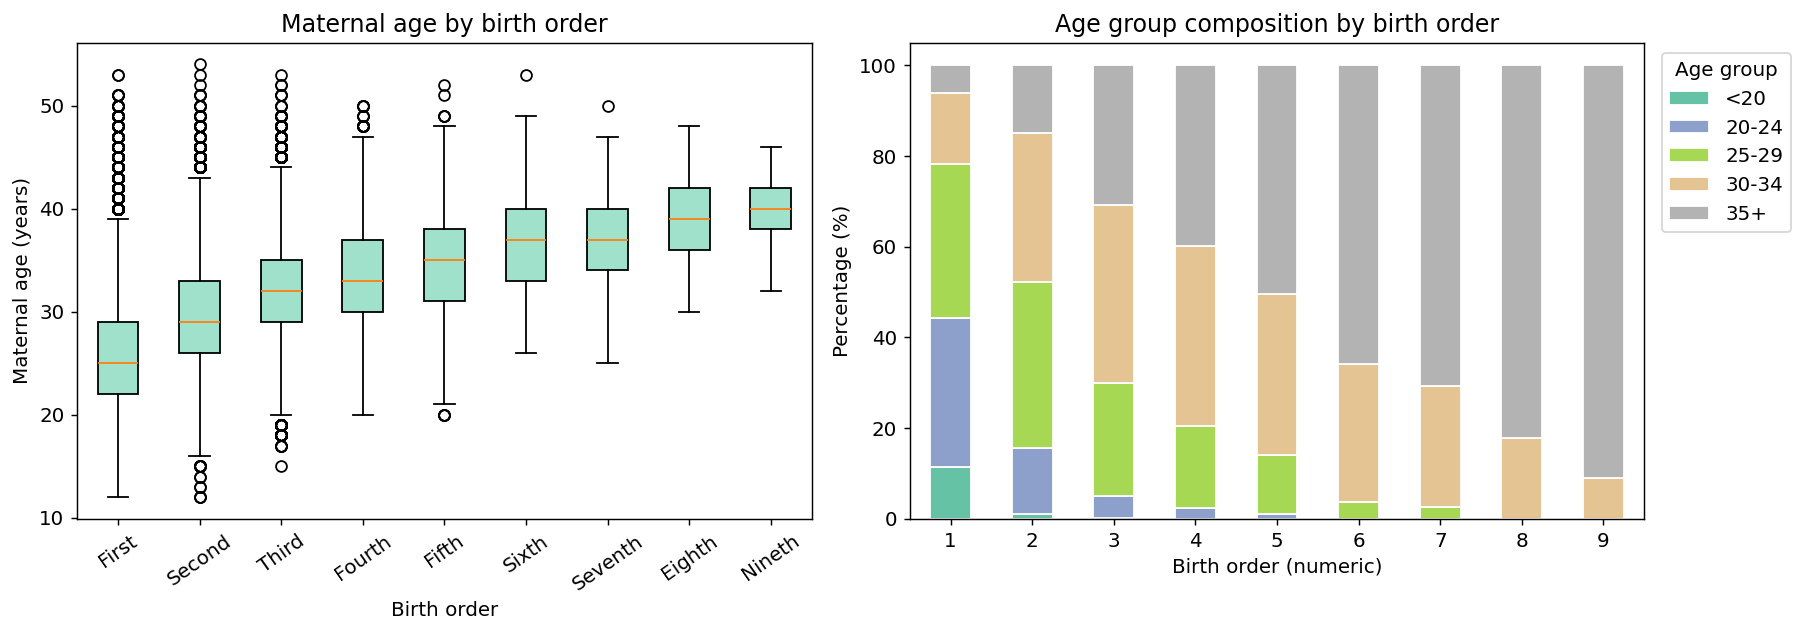

Saved: fig2_age_by_parity.png


In [43]:
# 3.2  Maternal age by birth order
parity_order = sorted(df['parity'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
box_data = [df[df['parity'] == p]['maternal_age'].values for p in parity_order]
bp = axes[0].boxplot(box_data,
                     labels=[ORDER_LABELS[p-1] for p in parity_order],
                     patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#9FE1CB')
axes[0].set_title('Maternal age by birth order')
axes[0].set_xlabel('Birth order')
axes[0].set_ylabel('Maternal age (years)')
axes[0].tick_params(axis='x', rotation=35)

# Stacked bar — age group composition
age_parity = pd.crosstab(df['parity'], df['age_group'], normalize='index') * 100
age_parity.plot(kind='bar', stacked=True, ax=axes[1],
                colormap='Set2', edgecolor='white')
axes[1].set_title('Age group composition by birth order')
axes[1].set_xlabel('Birth order (numeric)')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Age group', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('fig2_age_by_parity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_age_by_parity.png')

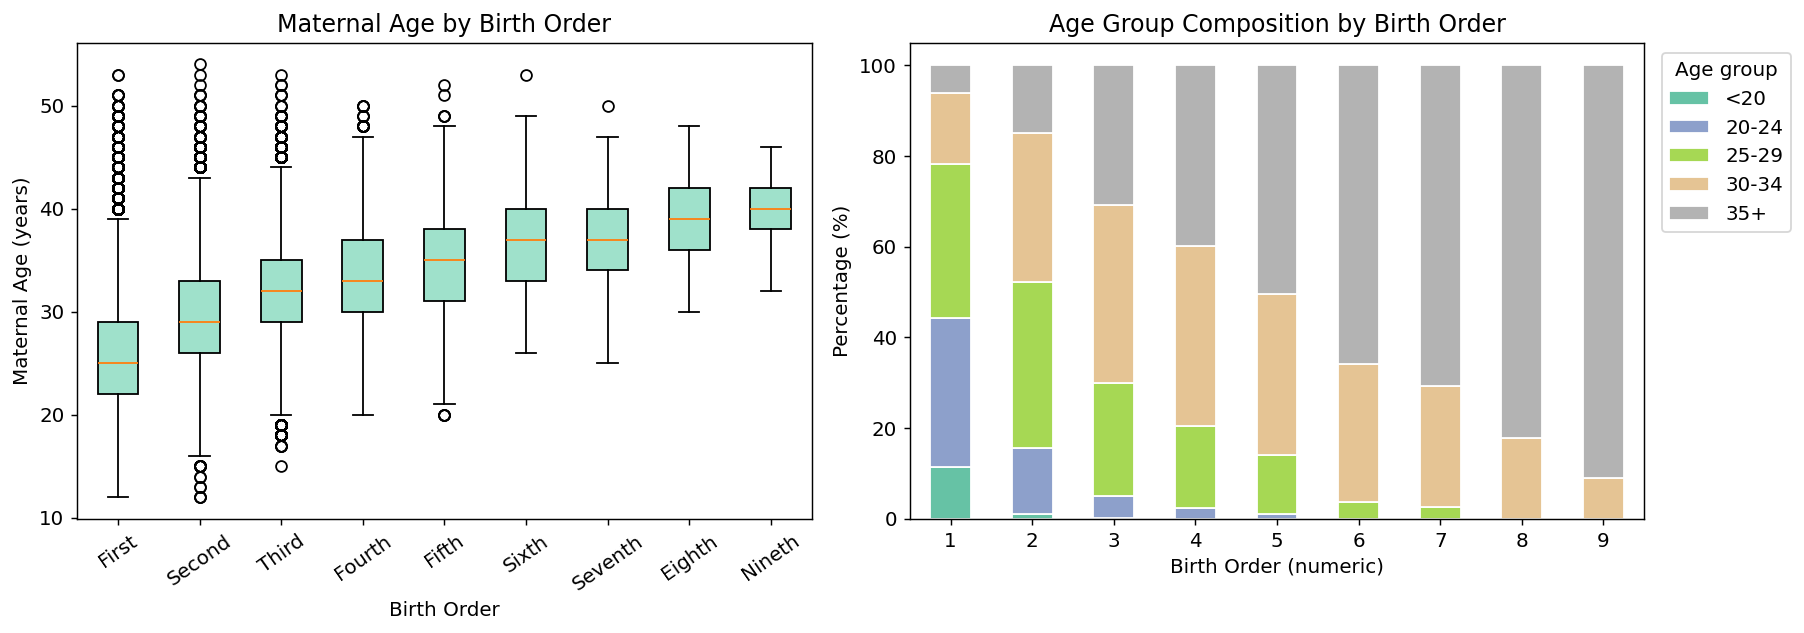

Saved: fig2_age_by_parity.png

Table 1: Maternal Age Descriptive Statistics by Birth Order
Birth Order  Parity      N    Mean  Median  Std Dev  Min  Max      Q1      Q3
      First       1 141383 25.6900 25.0000   5.2300   12   53 22.0000 29.0000
     Second       2 108642 29.4400 29.0000   4.8300   12   54 26.0000 33.0000
      Third       3  49739 32.1100 32.0000   4.7500   15   53 29.0000 35.0000
     Fourth       4  12941 33.4200 33.0000   4.7200   20   50 30.0000 37.0000
      Fifth       5   4007 34.6300 35.0000   4.6700   20   52 31.0000 38.0000
      Sixth       6   1040 36.5500 37.0000   4.2800   26   53 33.0000 40.0000
    Seventh       7    381 36.9200 37.0000   4.1400   25   50 34.0000 40.0000
     Eighth       8    124 38.7200 39.0000   4.2000   30   48 36.0000 42.0000
     Nineth       9     33 39.7600 40.0000   3.4100   32   46 38.0000 42.0000

Table 2: Age Group Composition (%) by Birth Order
age_group       <20   20-24   25-29   30-34     35+
Birth Order               

In [44]:
# 3.2  Maternal age by birth order — charts + Word doc export
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT

parity_order = sorted(df['parity'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Boxplot ─────────────────────────────────────────────────────────────────
box_data = [df[df['parity'] == p]['maternal_age'].values for p in parity_order]
bp = axes[0].boxplot(box_data,
                     labels=[ORDER_LABELS[p-1] for p in parity_order],
                     patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#9FE1CB')
axes[0].set_title('Maternal Age by Birth Order')
axes[0].set_xlabel('Birth Order')
axes[0].set_ylabel('Maternal Age (years)')
axes[0].tick_params(axis='x', rotation=35)

# ── Stacked bar ──────────────────────────────────────────────────────────────
age_parity = pd.crosstab(df['parity'], df['age_group'], normalize='index') * 100
age_parity.plot(kind='bar', stacked=True, ax=axes[1],
                colormap='Set2', edgecolor='white')
axes[1].set_title('Age Group Composition by Birth Order')
axes[1].set_xlabel('Birth Order (numeric)')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Age group', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('fig2_age_by_parity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_age_by_parity.png')

# ── Table 1: Descriptive stats for maternal age by birth order ───────────────
stats_rows = []
for p in parity_order:
    ages = df[df['parity'] == p]['maternal_age'].dropna()
    stats_rows.append({
        'Birth Order' : ORDER_LABELS[p - 1],
        'Parity'      : int(p),
        'N'           : len(ages),
        'Mean'        : round(ages.mean(), 2),
        'Median'      : round(ages.median(), 2),
        'Std Dev'     : round(ages.std(), 2),
        'Min'         : round(ages.min(), 1),
        'Max'         : round(ages.max(), 1),
        'Q1'          : round(ages.quantile(0.25), 2),
        'Q3'          : round(ages.quantile(0.75), 2),
    })

stats_df = pd.DataFrame(stats_rows)
print('\nTable 1: Maternal Age Descriptive Statistics by Birth Order')
print(stats_df.to_string(index=False))

# ── Table 2: Age group composition (%) by birth order ───────────────────────
age_parity_counts = pd.crosstab(df['parity'], df['age_group'])
age_parity_pct    = (age_parity_counts.div(age_parity_counts.sum(axis=1), axis=0) * 100).round(2)
age_parity_pct.index = [ORDER_LABELS[p - 1] for p in age_parity_pct.index]
age_parity_pct.index.name = 'Birth Order'
print('\nTable 2: Age Group Composition (%) by Birth Order')
print(age_parity_pct.to_string())

# ── Export to Word ───────────────────────────────────────────────────────────
doc = Document()

# Title
h = doc.add_heading('Section 3.2 — Maternal Age by Birth Order', level=1)
h.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph('')

# Figure
doc.add_heading('Figure 2: Maternal Age by Birth Order', level=2)
doc.add_picture('fig2_age_by_parity.png', width=Inches(6.2))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph('')

# ── Helper: write a styled table ─────────────────────────────────────────────
def add_styled_table(doc, dataframe, title, note=''):
    doc.add_heading(title, level=2)
    
    # Reset index so it becomes a column
    df_out = dataframe.reset_index() if dataframe.index.name else dataframe.copy()
    cols = df_out.columns.tolist()
    
    tbl = doc.add_table(rows=1 + len(df_out), cols=len(cols))
    tbl.style = 'Table Grid'
    tbl.alignment = WD_TABLE_ALIGNMENT.CENTER

    # Header
    for i, col in enumerate(cols):
        cell = tbl.rows[0].cells[i]
        cell.text = str(col)
        run = cell.paragraphs[0].runs[0]
        run.bold = True
        run.font.size = Pt(10)
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Data rows
    for r_idx, row in df_out.iterrows():
        row_cells = tbl.rows[r_idx + 1].cells
        for c_idx, val in enumerate(row):
            if isinstance(val, float):
                row_cells[c_idx].text = f'{val:.2f}'
            elif isinstance(val, int):
                row_cells[c_idx].text = f'{val:,}'
            else:
                row_cells[c_idx].text = str(val)
            row_cells[c_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

    if note:
        doc.add_paragraph('')
        p = doc.add_paragraph(f'Note: {note}')
        p.runs[0].italic = True
        p.runs[0].font.size = Pt(9)
    doc.add_paragraph('')

# Table 1 — Descriptive stats
add_styled_table(
    doc, stats_df,
    title='Table 1: Maternal Age Descriptive Statistics by Birth Order',
    note='N = number of births. Q1/Q3 = 25th/75th percentile of maternal age.'
)

# Table 2 — Age group composition
add_styled_table(
    doc, age_parity_pct,
    title='Table 2: Age Group Composition (%) by Birth Order',
    note='Values represent the percentage of mothers in each age group within each birth order category.'
)

doc_path = 'maternal_age_by_parity_report.docx'
doc.save(doc_path)
print(f'\nWord document saved: {doc_path}')


KeyError: 'place_of_delivery'

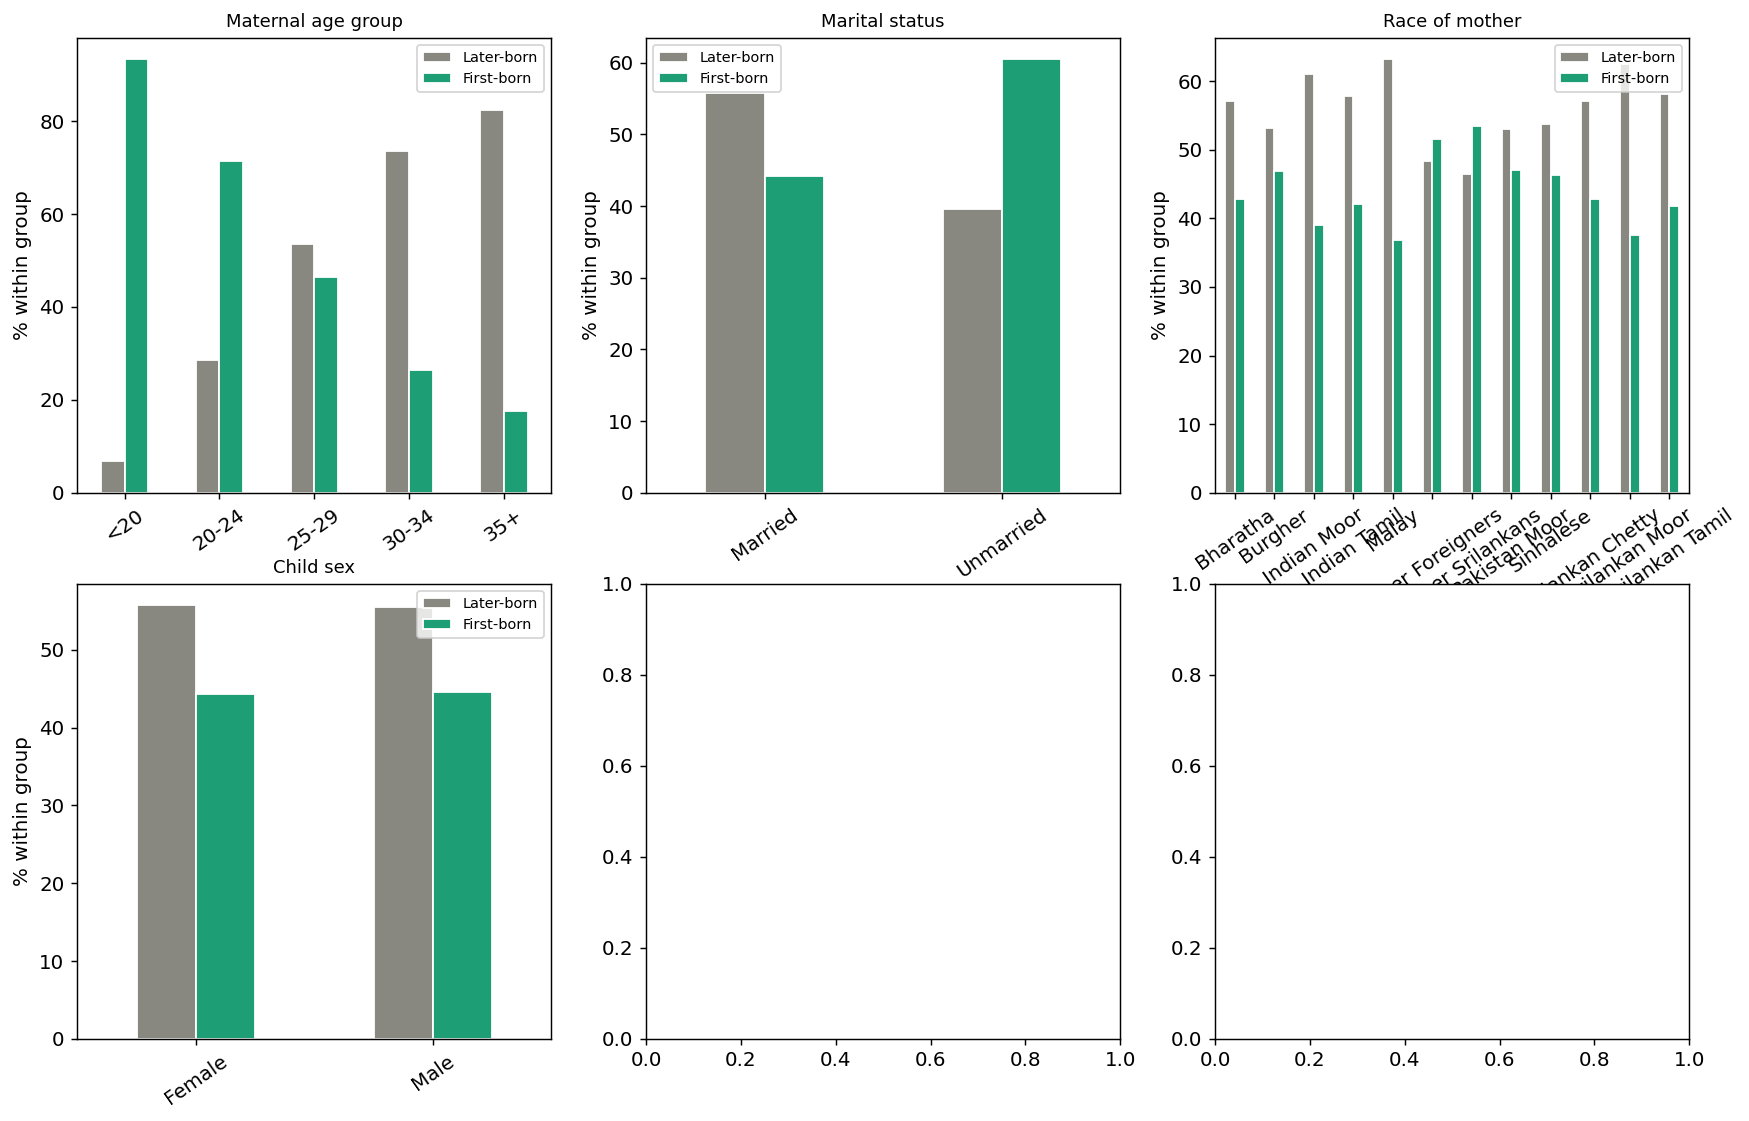

In [45]:
# 3.3  Categorical predictors vs first-birth (parity_binary)
PLOT_VARS = [
    ('age_group',        'Maternal age group'),
    ('marital_status',   'Marital status'),
    ('race_mother',      'Race of mother'),
    ('child_sex',        'Child sex'),
    ('place_of_delivery','Place of delivery'),
    ('multiple_birth',   'Multiple birth'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (var, label) in zip(axes, PLOT_VARS):
    ct = pd.crosstab(df[var], df['parity_binary'], normalize='index') * 100
    ct.columns = ['Later-born', 'First-born']
    ct.plot(kind='bar', ax=ax,
            color=['#888780', '#1D9E75'], edgecolor='white')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('% within group')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=8)

plt.suptitle('First-birth proportion by maternal & birth characteristics',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_predictors_vs_parity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_predictors_vs_parity.png')